In [2]:
from typing import *
import random
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    name : str
    numbers : list[int]
    counter : int

In [17]:
def greetingNode(state : AgentState) -> AgentState:
    """
    This node greets the user
    """
    state["name"] = f"hi,{state['name']}"
    state["counter"] = 0
    return state

def randomNumberNode(state : AgentState) -> AgentState:
    """
    This node generates a random number
    """
    state["numbers"].append(random.randint(0, 10))
    state["counter"] += 1
    return state

def decisionNode(state : AgentState) -> AgentState:
    """
    This node decides whether to continue the loop. We need to return the edgename
    """

    if state["counter"] < 5:
        return "loopingEdge"
    else:
        return "exitEdge"
    

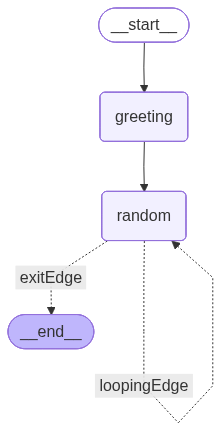

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greetingNode)
graph.add_node("random", randomNumberNode)
graph.add_edge("greeting", "random")


graph.add_conditional_edges(
    "random", # Source Node
    decisionNode, # Action/ Decision function
    {
        "loopingEdge" : "random",
        "exitEdge" : END
    })

graph.set_entry_point("greeting")
graph.compile()